In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FREEZE = pd.Timestamp("2025-01-20")
df = pd.read_excel("Africa_CDC_Merged_through_July2026.xlsx")
df["Report Date"] = pd.to_datetime(df["Report Date"], errors="coerce")
df["month"] = df["Report Date"].dt.to_period("M").dt.to_timestamp()
df["post"] = (df["Report Date"] >= FREEZE).astype(int)

print("Rows:", len(df), "| Columns:", df.shape[1])
print("Date range:", df["Report Date"].min().date(), "->", df["Report Date"].max().date())
print("Countries:", df["Country"].nunique(), "| Diseases:", df["Agent/Syndrome"].nunique())

Rows: 2878 | Columns: 67
Date range: 2023-12-18 -> 2026-07-19
Countries: 41 | Diseases: 30


In [3]:
usaid = "USAID share of total ODA gross disbursements received, 2023"
cu = df.groupby("Country")[usaid].first()
cutoff = cu.median()
high = cu[cu >= cutoff].index
df["treated"] = df["Country"].isin(high).astype(int)
print(f"Median USAID-share cutoff: {cutoff:.3f}")
print(f"High-dependence (treated): {len(high)} | Low: {df['Country'].nunique()-len(high)}")

Median USAID-share cutoff: 0.120
High-dependence (treated): 21 | Low: 20


In [4]:
oda_pc = "ODA gross disbursements received per person, 2023 (USD)"
oda_tot = "ODA gross disbursements received, 2023 (USD millions)"
pc = df.groupby("Country").agg(usaid_share=(usaid,"first"),
        oda_pp=(oda_pc,"first"), oda_tot=(oda_tot,"first")).reset_index()
print(f"Mean USAID share of ODA : {pc['usaid_share'].mean():.3f}")
print(f"Mean ODA per person     : ${pc['oda_pp'].mean():.1f}")
print(f"Mean total ODA          : ${pc['oda_tot'].mean():.0f}m")

Mean USAID share of ODA : 0.137
Mean ODA per person     : $78.0
Mean total ODA          : $1512m


In [5]:
dis = df.groupby("Agent/Syndrome").agg(
        n_reports=("Country","size"), n_countries=("Country","nunique")
      ).reset_index().sort_values("n_reports", ascending=False)
dis.head(12)

,Agent/Syndrome,n_reports,n_countries
26,Vibrio cholerae,779,26
14,Mpox virus,720,30
13,Measles virus,614,27
6,Dengue virus,248,12
17,Polio virus (vaccine-derived),107,14
2,Bacterial meningitis,81,5
5,Corynebacterium diphtheriae,74,8
11,Lassa virus,47,4
28,Yellow fever virus,37,7
19,Rift Valley Fever,29,3


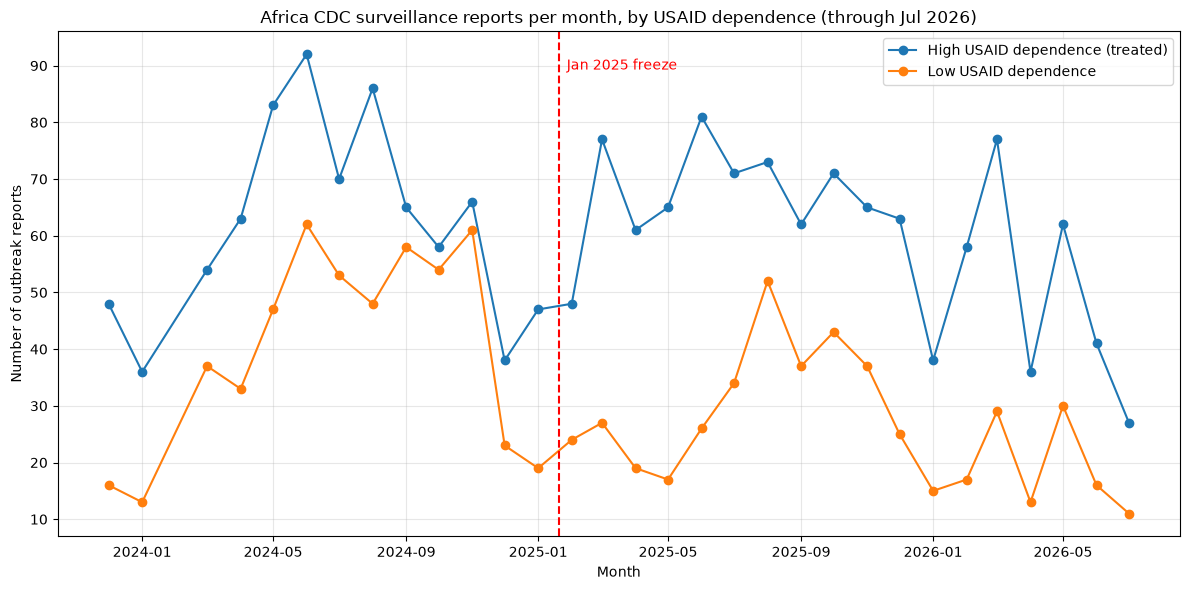

In [6]:
monthly = df.groupby(["month","treated"]).size().reset_index(name="n")
pv = monthly.pivot(index="month", columns="treated", values="n").fillna(0)
pv.columns = ["Low USAID dependence","High USAID dependence"]
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(pv.index, pv["High USAID dependence"], marker="o", label="High USAID dependence (treated)")
ax.plot(pv.index, pv["Low USAID dependence"], marker="o", label="Low USAID dependence")
ax.axvline(FREEZE, color="red", ls="--", lw=1.5)
ax.text(FREEZE, ax.get_ylim()[1]*0.95, "  Jan 2025 freeze", color="red", va="top")
ax.set_title("Africa CDC surveillance reports per month, by USAID dependence (through Jul 2026)")
ax.set_xlabel("Month"); ax.set_ylabel("Number of outbreak reports")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [7]:
pre = pv[pv.index < FREEZE]
print(f"Pre-freeze correlation between groups: {pre['Low USAID dependence'].corr(pre['High USAID dependence']):.3f}")

Pre-freeze correlation between groups: 0.782


In [8]:
tab = df.groupby(["Country","treated","post"]).size().unstack("post", fill_value=0)
tab.columns = ["pre_freeze","post_freeze"]; tab["total"] = tab.sum(axis=1)
pre_c = tab["pre_freeze"].astype(float); post_c = tab["post_freeze"].astype(float)
tab["pct_change"] = np.where(pre_c>0,(post_c-pre_c)/pre_c*100,np.nan).round(1)
tab.reset_index().sort_values("total", ascending=False)

,Country,treated,pre_freeze,post_freeze,total,pct_change
20,Mali,1,91,215,306,136.3
27,Nigeria,1,90,79,169,-12.2
3,Burundi,0,77,91,168,18.2
10,Democratic Republic of the Congo,1,85,70,155,-17.6
24,Mozambique,1,37,117,154,216.2
30,Senegal,0,53,87,140,64.2
15,Kenya,1,39,82,121,110.3
11,Ethiopia,1,65,37,102,-43.1
35,Sudan,1,28,71,99,153.6
5,Cameroon,0,44,50,94,13.6


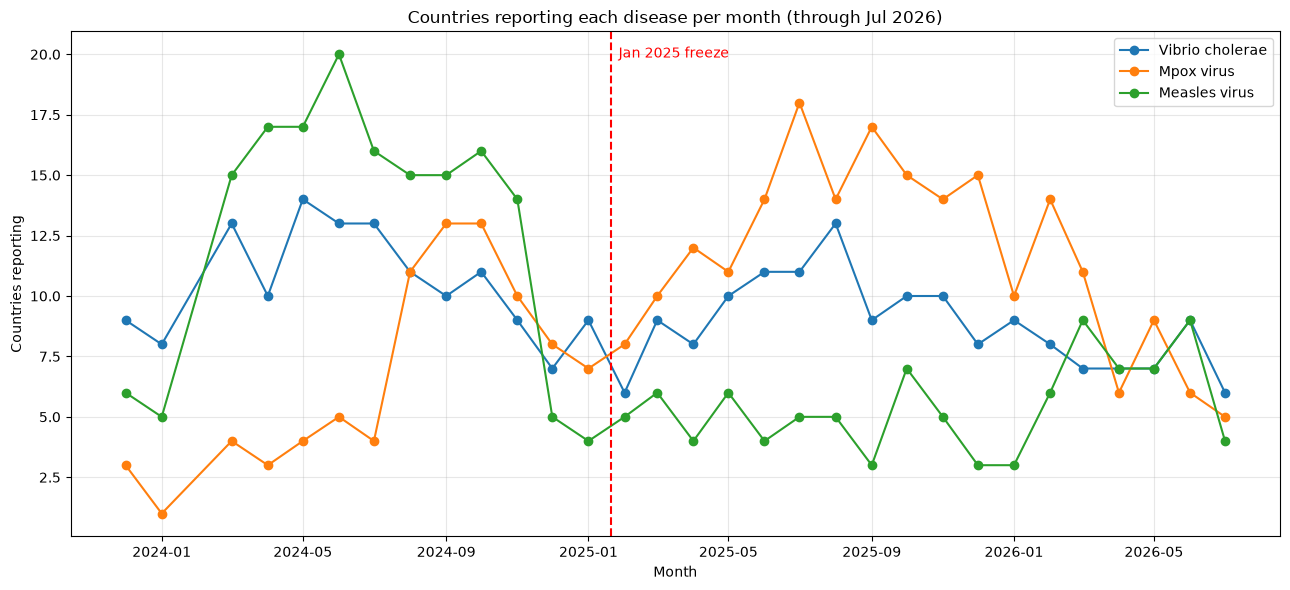

In [9]:
top = ["Vibrio cholerae","Mpox virus","Measles virus"]
sub = df[df["Agent/Syndrome"].isin(top)]
cnt = sub.groupby(["month","Agent/Syndrome"])["Country"].nunique().reset_index(name="n")
pv2 = cnt.pivot(index="month", columns="Agent/Syndrome", values="n").fillna(0)
fig, ax = plt.subplots(figsize=(13,6))
for d in top:
    if d in pv2.columns: ax.plot(pv2.index, pv2[d], marker="o", label=d)
ax.axvline(FREEZE, color="red", ls="--", lw=1.5)
ax.text(FREEZE, ax.get_ylim()[1]*0.97, "  Jan 2025 freeze", color="red", va="top")
ax.set_title("Countries reporting each disease per month (through Jul 2026)")
ax.set_xlabel("Month"); ax.set_ylabel("Countries reporting")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [10]:
import pandas as pd
df = pd.read_excel("Africa_CDC_Merged_through_July2026.xlsx")
df["Report Date"] = pd.to_datetime(df["Report Date"], errors="coerce")
new = df[df["Report Date"] >= "2026-02-01"]

print("Disease labels in the 2026 rows:")
print(new["Agent/Syndrome"].value_counts().to_string())

Disease labels in the 2026 rows:
Agent/Syndrome
Vibrio cholerae                  119
Mpox virus                       100
Measles virus                     91
Dengue virus                      31
Polio virus (vaccine-derived)     20
Bacterial meningitis              14
Corynebacterium diphtheriae       13
Ebola virus                       12
Chikungunya virus                  3
CCHF virus                         3
Floods                             2
UNKNOWN: *                         2
UNKNOWN: ~~                        2
Bacillus anthracis                 1
UNKNOWN: A                         1
UNKNOWN: @                         1
UNKNOWN: virus                     1
UNKNOWN: disease                   1


In [13]:
import pandas as pd
from IPython.display import display

dropouts = pd.read_csv("measles_dropouts_table.csv")
print("Countries that stopped reporting measles entirely after the Jan 2025 freeze")
print("(but kept reporting other diseases — see other_dis_post column)\n")
display(dropouts)

Countries that stopped reporting measles entirely after the Jan 2025 freeze
(but kept reporting other diseases — see other_dis_post column)



,Country,measles_pre,measles_post,other_dis_post,usaid_share
0,Ethiopia,24,0,37,0.266
1,Mauritania,15,0,29,0.033
2,Central African Republic,12,0,10,0.158
3,Burkina Faso,9,0,1,0.099
4,South Sudan,6,0,34,0.364
5,Nigeria,3,0,79,0.185
6,Togo,3,0,22,0.017
7,Cote d'Ivoire,1,0,10,0.045
